In [16]:
#Code cell adapted from 1d_energy_comparison.ipynb in the pvqz_basis_set_comparison folder
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from scipy.optimize import curve_fit
hartree_to_cm = 219474.6313705

def load_coords_energy(file_name):
    """loads in unsorted basis set energy files"""
    #sort file by coordinates first
    energy_file = np.loadtxt(file_name)
    sort_idx = np.argsort(energy_file[:,7])
    energy_file = energy_file[sort_idx]
    
    #convert hartree to wavenumber, set minimum
    energy_file[:,6] = energy_file[:,6]*hartree_to_cm
    energy_file[:,6] = energy_file[:,6] - min(energy_file[:,6])
    
    #separate coords and energy
    return (energy_file[:,:6], energy_file[:,6])

(-0.5, 1000.0)

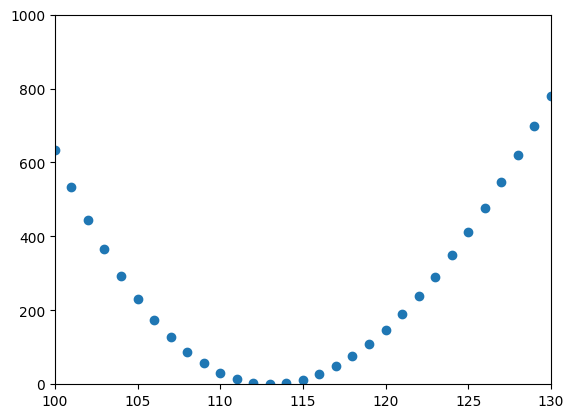

In [17]:
apoh_coords, E_apoh = load_coords_energy('apoh_1d.txt')
apoh = apoh_coords[:,4]*np.pi/180
w = (np.tanh(-0.008*(E_apoh - 2000)) + 1.002002002) / 2.002002002
#print(apoh)
#print(E_apoh)

plt.figure()
plt.plot(apoh*180/np.pi, E_apoh, 'o')
plt.xlim(100,130)
plt.ylim(-0.5, 1000)

[9.94007296e+03 2.00852646e+00]


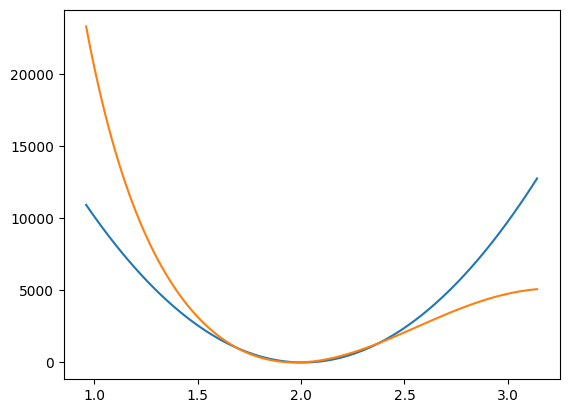

In [18]:
popt, pcov = curve_fit(lambda x, a, xe: a*(x-xe)**2, apoh, E_apoh, 
                       [10000, 1.97],
                       sigma = 1/w
                       )
print(popt)

plt.figure()
plt.plot(apoh, (lambda x, a, xe: a*(x-xe)**2)(apoh, popt[0], popt[1]))
plt.plot(apoh, E_apoh)

[5.17153839e+05 1.66595286e-01 1.97401073e+00]
113.10248358268024
[1.15414383e+05 1.86019028e-02 3.02553331e-03]


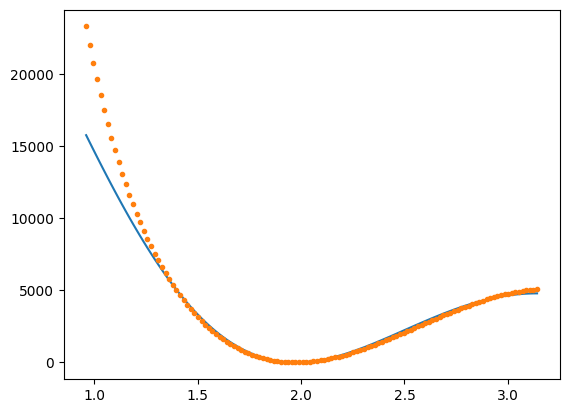

In [23]:
w = (np.tanh(-0.008*(E_apoh - 8000)) + 1.002002002) / 2.002002002
popt, pcov = curve_fit(lambda x, a, b, xe: a*(1-np.exp(b*(np.cos(x)-np.cos(xe))))**2, apoh, E_apoh, 
                       [10000, 1.5, 1.97],
                       sigma = 1/w
                       )
print(popt)
print(popt[2]*180/np.pi)
print(np.sqrt(np.diag(pcov)))

predict_apoh = (lambda x, a, b, xe: 
                a*(1-np.exp(b*(np.cos(x)-np.cos(xe))))**2)(apoh, popt[0], popt[1], popt[2])
plt.figure()
plt.plot(apoh, predict_apoh)
plt.plot(apoh, E_apoh, '.')

127.1378646356286


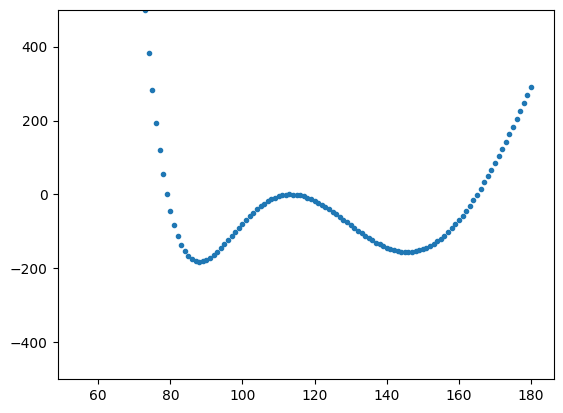

In [24]:
plt.figure()
plt.plot(apoh*180/np.pi, E_apoh-predict_apoh, '.')
plt.ylim(-500,500)

print(np.sqrt(np.sum(((E_apoh-predict_apoh)*(np.sqrt(w)))**2)/len(E_apoh)))

[ 1.96807033e+00  3.15849438e-01  1.23901934e+05 -9.20394853e+00
  8.54224439e+02  5.33181130e+01 -1.38041120e+03 -3.63675752e+03
  1.37867131e+04]
112.76212386287936
[1.00776864e-03 9.12592846e+01 1.61212648e+08 4.78031850e+00
 1.01707126e+07 2.52975140e+06 4.12721279e+05 6.25946239e+04
 9.65020494e+03]


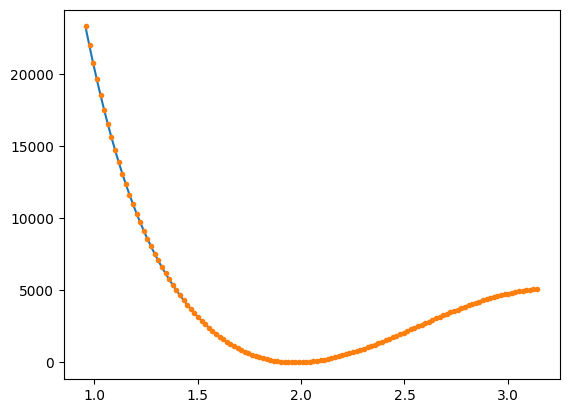

In [61]:
def morse_cos(x, xe, a):
    return 1 - np.exp(a*(np.cos(x)-np.cos(xe)))

def morse_fit(x, xe, a, b, c0, c2, c3, c4, c5, c6):
    z = morse_cos(x, xe, a)**2
    y = np.cos(x) - np.cos(xe)

    return b*z + c0 + c2*y**2 + c3*y**3 + c4*y**4 + c5*y**5 + c6*y**6


w = (np.tanh(-0.008*(E_apoh - 20000)) + 1.002002002) / 2.002002002
popt, pcov = curve_fit(morse_fit, apoh, E_apoh, 
                       [1.974, 0.166, 70000, 20, 2000, 1000, 500, 2000, 1000],
                       sigma = 1/w
                       )

print(popt)
print(popt[0]*180/np.pi)
print(np.sqrt(np.diag(pcov)))


predict_apoh = morse_fit(apoh, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5], popt[6], popt[7], popt[8])
plt.figure()
plt.plot(apoh, predict_apoh)
plt.plot(apoh, E_apoh, '.')

[ 7.47911534e+00  4.85925617e+00  2.89171008e+00  4.57173850e+01
  1.39901558e+01 -6.83425954e+00 -1.90764018e+01 -2.47753379e+01
 -2.56580013e+01 -2.31684591e+01 -1.84960680e+01 -1.26027713e+01
 -6.24896330e+00 -1.81907443e-02  5.65971207e+00  1.04867437e+01
  1.42768034e+01  1.69368741e+01  1.84501675e+01  1.88606896e+01
  1.82592446e+01  1.67710633e+01  1.45447956e+01  1.17429063e+01
  8.53328675e+00  5.08232945e+00  1.54893607e+00 -1.91999749e+00
 -5.19333166e+00 -8.15828811e+00 -1.07221449e+01 -1.28131279e+01
 -1.43807376e+01 -1.53951581e+01 -1.58465589e+01 -1.57435180e+01
 -1.51115496e+01 -1.39909183e+01 -1.24346735e+01 -1.05061474e+01
 -8.27666698e+00 -5.82310920e+00 -3.22545222e+00 -5.64555275e-01
  2.08004111e+00  4.63220203e+00  7.02090881e+00  9.18192755e+00
  1.10591169e+01  1.26054340e+01  1.37839003e+01  1.45679370e+01
  1.49418249e+01  1.49006837e+01  1.44501625e+01  1.36061897e+01
  1.23942097e+01  1.08484155e+01  9.01082582e+00  6.93010403e+00
  4.66032406e+00  2.25971

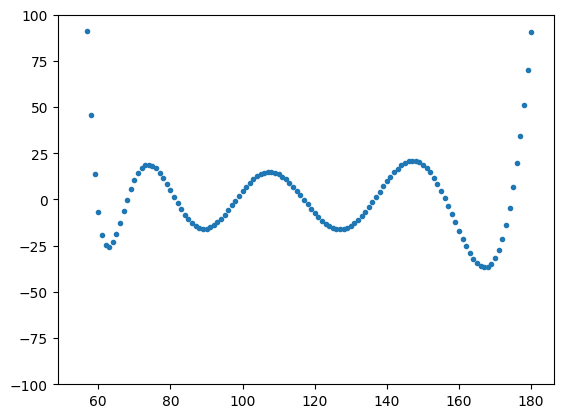

In [62]:
plt.figure()
plt.plot(apoh*180/np.pi, E_apoh-predict_apoh, '.')
plt.ylim(-100,100)

#print(E_apoh - predict_apoh)
print((E_apoh-predict_apoh)*(np.sqrt(w)))

print(np.sqrt(np.sum(((E_apoh-predict_apoh)*(np.sqrt(w)))**2)/len(E_apoh)))